Accreted Milky Way Globular Clusters


Using data from the Harris Catalogue of Milky Way globular clusters and vandenBerg et al. (2013), use
stellar population (metallicities [Fe/H] and ages) and dynamical information to identify potentially
accreted globular clusters. Consider if there are some globular clusters that stand out in the age-metallicity relation or that do not rotate with the bulk of other globular clusters.
Consider what the above findings might mean for how the Milky Way formed and how many of its
globular clusters could be accreted and how many may have formed within the Milky Way. Consider
what further tests could be performed to delineate various possible formation scenarios.

In [2]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from mpdaf.obj import Image
from astropy.visualization import make_lupton_rgb
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Distance, Galactic, EarthLocation
from astropy.table import Table, QTable
import plotly.express as px

In [3]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 

## Data Info

*Harris: CATALOG OF PARAMETERS FOR MILKY WAY GLOBULAR CLUSTERS*

**Harris Part I - Cluster identifications and positions**
- ['RA'], ['DEC'] Right ascention and Declination (epoch J2000)
- ['L'], ['B'] Galactic longitude and latitude (degrees)
- ['R_Sun'] Distance from Sun (kiloparsecs)
- ['R_gc'] Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- ['X'], ['Y'], ['Z'] Galactic distance components X,Y,Z in kiloparsecs, in a Sun-centered coordinate system; X points toward Galactic center, Y in direction of Galactic rotation, Z toward North Galactic Pole

**Harris Part II - Metallicities, Integrated magnitudes, colors**
- ['Fe/H'] Metallicity [Fe/H]
- ['wt'] Weight of mean metallicity; essentially the number of independent [Fe/H] measurements averaged together.
- ['E(B-V)'] Foreground reddening
- ['V_HB'] V magnitude level of the horizontal branch (or RR Lyraes)
- ['(m-M)V'] Apparent visual distance modulus
- ['V_t'] Integrated V magnitude of the cluster
- ['M_V,t'] Absolute visual magnitude (cluster luminosity),  M_V,t = V_t - (m-M)V
- ['U-B'], ['B-V'], ['V-R'], ['V-I'] Integrated color indices (uncorrected for reddening)
- ['spt] Spectral type of the integrated cluster light
- ['ellip'] Projected ellipticity of isophotes, e = 1-(b/a)

**Harris Part III - Radial velocities, velocity dispersions, structural parameters**
- ['v_r'] Heliocentric radial velocity (km/s)
- ['v_r_e'] Observational (internal) uncertainty in radial velocity
- ['v_LSR'] Radial velocity relative to Solar neighborhood LSR
- ['sig_v'] Central velocity dispersion sig_v (km/s)
- ['sig_v_e'] Observational (internal) uncertainty in velocity dispersion
- ['c'] King-model central concentration, c = log(r_t/r_c); a 'c' denotes a core-collapsed cluster
- ['r_c'] Core radius in arcmin
- ['r_h'] Half-light radius in arcmin
- ['mu_V'] Central surface brightness, V magnitudes per square arcsecond
- ['rho_0'] Central luminosity density, log_10(Solar luminosities per cubic parsec)
- ['lg_tc'] Core relaxation time t(r_c), in log_10(years)
- ['lg_th'] Median relaxation time t(r_h), in log_10(years)

**Krause**
- ['Mstar'] Stellar mass (Mstar) of the object
- ['rh'] Half-light radius (rh) of the object
- ['C5'] Compactness parameter (C5) of the object
- ['Age'] Age of the object (Gyr)
- ['FeH'] Metallicity [Fe/H]

**VandenBerg**
- ['FeH'] Metallicity [Fe/H]
- ['Age'] Age of the object (Gyr)
- ['Age_err'] Age uncertainty
- ['Method']
- ['Figs']
- ['Range']
- ['HBtype']
- ['R_G'] Distance from Galactic center (kpc)
- ['M_V'] Absolute visual magnitude
- ['v_e0'] Central escape velocity
- ['log_sigma_0'] Central logarithmic velocity dispersion

In [4]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p1.head()

,Object,Name,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z
0,NGC104,47 Tuc,00:24:05.67,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1
1,NGC288,NaN,00:52:45.24,-26:34:57.4,152.30,-89.38,8.9,12.0,-0.1,0.0,-8.9
2,NGC362,NaN,01:03:14.26,-70:50:55.6,301.53,-46.25,8.6,9.4,3.1,-5.1,-6.2
3,Whiting1,NaN,02:02:57,-03:15:10,161.22,-60.76,30.1,34.5,-13.9,4.7,-26.3
4,NGC1261,NaN,03:12:16.21,-55:12:58.4,270.54,-52.12,16.3,18.1,0.1,-10.0,-12.9


In [5]:
# IGNORE HARRIS P2 FOR NOW
harris_p2.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p2['Object'] = harris_p2['Object'].astype(str) # make sure object column is string type
harris_p2['Object'] = harris_p2['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p2.head()

,Object,[Fe/H],wt,E(B-V),V_HB,(m-M)V,V_t,"M_V,t",U-B,B-V,V-R,V-I,spt,ellip
0,NGC104,-0.72,10,0.04,14.06,13.37,3.95,-9.42,0.37,0.88,0.53,1.14,G4,0.09
1,NGC288,-1.32,3,0.03,15.44,14.84,8.09,-6.75,0.08,0.65,0.45,0.94,,
2,NGC362,-1.26,5,0.05,15.44,14.83,6.4,-8.43,0.16,0.77,0.49,1.01,F9,0.01
3,Whiting1,-0.7,1,0.03,18.18,17.49,15.03,-2.46,,,,,,
4,NGC1261,-1.27,3,0.01,16.70,16.09,8.29,-7.8,0.13,0.72,0.45,0.93,F7,0.07


In [6]:
# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p3.head()

,Object,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th
0,NGC104,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55
1,NGC288,-45.4,0.2,-51.9,2.9,0.3,0.99,1.35,2.23,20.05,1.78,8.99,9.32
2,NGC362,223.5,0.5,214.0,6.4,0.3,1.76,0.18,0.82,14.80,4.74,7.76,8.93
3,Whiting1,-130.6,1.8,-138.1,NaN,NaN,0.55,0.25,0.22,NaN,NaN,NaN,7.93
4,NGC1261,68.2,4.6,54.9,NaN,NaN,1.16,0.35,0.68,17.73,2.99,8.59,9.12


In [7]:
# Krause: naming already consistent
krause.head() 

,Class,Object,AltName,Mstar,rh,C5,Age,FeH
0,GC,NGC104,47Tuc,6.46,7.10,0.92,12.80,-0.76
1,GC,NGC288,Melotte3,0.46,9.80,0.05,12.20,-1.32
2,GC,NGC362,Dunlop62,2.50,3.50,0.72,10.00,-1.26
3,GC,NGC1261,Caldwell87,3.41,5.50,0.62,10.24,-1.08
4,GC,NGC1851,Dunlop508,5.51,3.05,1.81,7.64,-1.13


In [8]:
# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
vandenberg.head()

,Object,Name,FeH,Age,Age_err,Method,Figs,Range,HBtype,R_G,M_V,v_e0,log_sigma_0
0,NGC104,47Tuc,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,-9.42,54.8,5.061
1,NGC288,XXXX,-1.32,11.50,0.38,H,24,NaN,0.98,12.0,-6.75,10.9,2.953
2,NGC362,XXXX,-1.30,10.75,0.25,V,13,10.75–11.00,-0.87,9.4,-8.43,44.4,4.938
3,NGC1261,XXXX,-1.27,10.75,0.25,V,13,10.75–11.25,-0.71,18.1,-7.80,23.6,3.913
4,NGC1851,XXXX,-1.18,11.00,0.25,V,13,10.75–11.25,-0.32,16.6,-8.33,47.6,5.136


In [9]:
# vandenberg data for NGC6121
vandenberg_feh = vandenberg[vandenberg['Object'] == 'NGC6121']['FeH'].values[0]
print(f"VandenBerg [Fe/H] for NGC6121: {vandenberg_feh}")
# krause data for NGC6121
krause_feh = krause[krause['Object'] == 'NGC6121']['FeH'].values[0]
print(f"Krause [Fe/H] for NGC6121: {krause_feh}")

VandenBerg [Fe/H] for NGC6121: -1.18
Krause [Fe/H] for NGC6121: -1.98


In [10]:
# merge data frames
merged_data = pd.merge(harris_p1, harris_p3, on='Object')
merged_data = pd.merge(merged_data, vandenberg, on='Object')
merged_data = pd.merge(merged_data, krause, on='Object')
merged_data.columns

Index(['Object', 'Name_x', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y',
       'Z', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h',
       'mu_V', 'rho_0', 'lg_tc', 'lg_th', 'Name_y', 'FeH_x', 'Age_x',
       'Age_err', 'Method', 'Figs', 'Range', 'HBtype', 'R_G', 'M_V', 'v_e0',
       'log_sigma_0', 'Class', 'AltName', 'Mstar', 'rh', 'C5', 'Age_y',
       'FeH_y'],
      dtype='object')

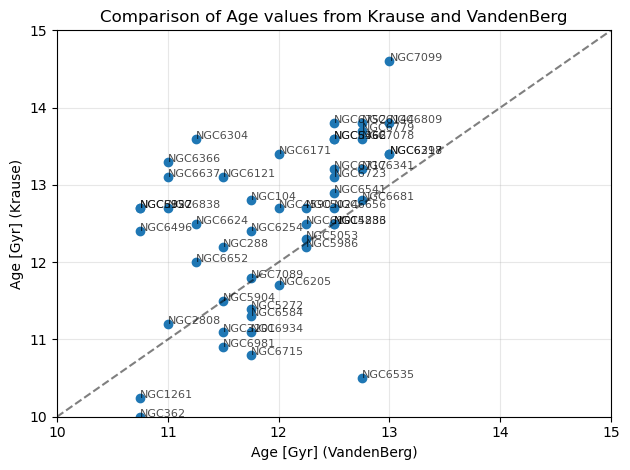

In [11]:
# plot the age values from krause vs vandenberg
plt.plot(merged_data['Age_x'], merged_data['Age_y'], 'o')
plt.xlabel('Age [Gyr] (VandenBerg)')
plt.ylabel('Age [Gyr] (Krause)')
# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['Age_x'][i], merged_data['Age_y'][i]), fontsize=8, alpha=0.7)

plt.plot([10, 15], [10, 15], 'k--', alpha=0.5) # plot 1:1 line
plt.xlim(10, 15)
plt.ylim(10, 15)
plt.grid(alpha=0.3)
plt.title('Comparison of Age values from Krause and VandenBerg')
plt.tight_layout()
plt.show()

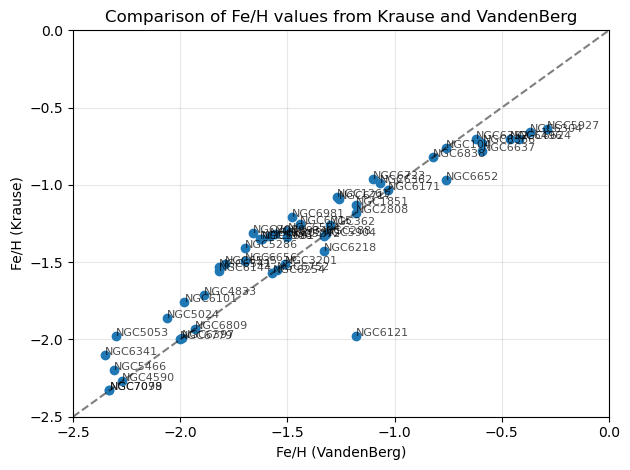

In [12]:
# plot the Fe/H values from krause vs vandenberg
plt.plot(merged_data['FeH_x'], merged_data['FeH_y'], 'o')
plt.xlabel('Fe/H (VandenBerg)')
plt.ylabel('Fe/H (Krause)')
# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['FeH_x'][i], merged_data['FeH_y'][i]), fontsize=8, alpha=0.7)
plt.plot([-2.5, 0], [-2.5, 0], 'k--', alpha=0.5) # 1:1 line
plt.xlim(-2.5, 0)
plt.ylim(-2.5, 0)
plt.grid(alpha=0.3)
plt.title('Comparison of Fe/H values from Krause and VandenBerg')
plt.tight_layout()
plt.show()

#there is slight discrepancy between the Fe/H values from the two sources

In [13]:
# combine the FeH and Age columns from vandenberg and krause by averaging them
merged_data['FeH'] = merged_data[['FeH_x', 'FeH_y']].mean(axis=1) # average the two FeH columns
merged_data['Age'] = merged_data[['Age_x', 'Age_y']].mean(axis=1)  # average the two Age columns
merged_data = merged_data.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y']) # drop the old columns
merged_data.columns

Index(['Object', 'Name_x', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y',
       'Z', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h',
       'mu_V', 'rho_0', 'lg_tc', 'lg_th', 'Name_y', 'Age_err', 'Method',
       'Figs', 'Range', 'HBtype', 'R_G', 'M_V', 'v_e0', 'log_sigma_0', 'Class',
       'AltName', 'Mstar', 'rh', 'C5', 'FeH', 'Age'],
      dtype='object')

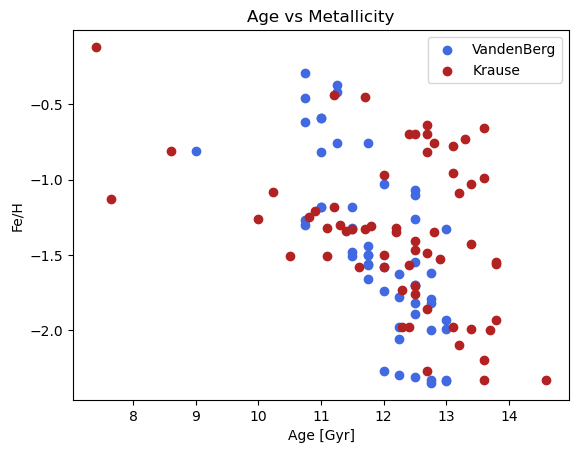

In [17]:
# Age-metallicity plot with data from VandenBerg and Krause
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='royalblue', label='VandenBerg')
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='firebrick', label='Krause')
plt.title('Age vs Metallicity')
plt.xlabel('Age [Gyr]')
plt.ylabel('Fe/H')
plt.legend()

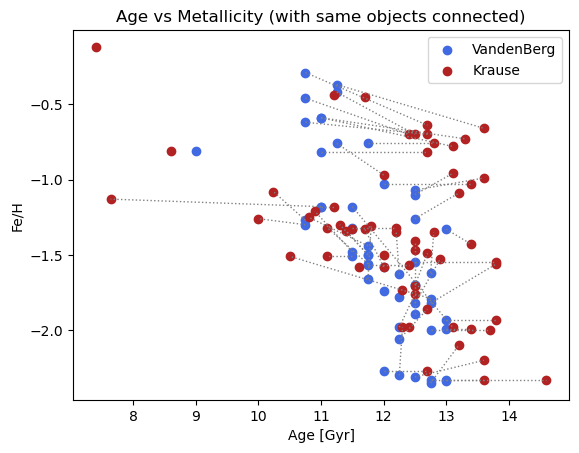

In [18]:
# Age-metallicity plot with data from VandenBerg and Krause with lines connecting matching objects
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='royalblue', label='VandenBerg')
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='firebrick', label='Krause')

# Connect matching objects
for object in set(vandenberg['Object']).intersection(krause['Object']): # find common objects
    v = vandenberg[vandenberg['Object'] == object].iloc[0] # get object row for vandenberg
    k = krause[krause['Object'] == object].iloc[0]  # get object row for krause
    plt.plot([v['Age'], k['Age']], [v['FeH'], k['FeH']],color='gray', linestyle=':', linewidth=1) # plot line between same objects

# labels
plt.title('Age vs Metallicity (with same objects connected)')
plt.xlabel('Age [Gyr]')
plt.ylabel('Fe/H')
plt.legend()
plt.show()


Text(0.5, 1.0, 'Age vs Metallicity (averaged data)')

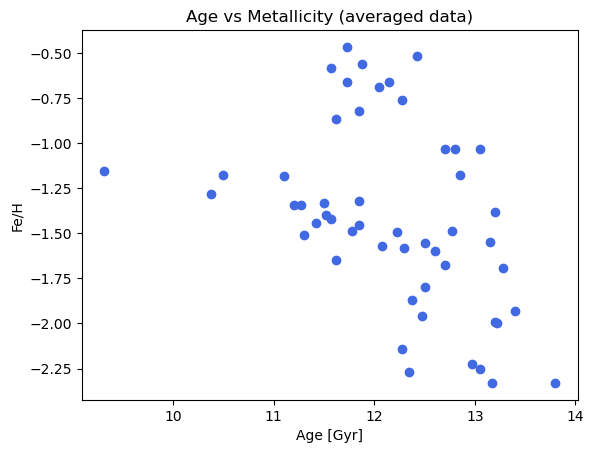

In [19]:
# age-metallicity plot with data averaged from VandenBerg and Krause
plt.scatter(merged_data['Age'], merged_data['FeH'], marker='o', c='royalblue')
plt.xlabel('Age [Gyr]')
plt.ylabel('Fe/H')
plt.title('Age vs Metallicity (averaged data)')

Try to find which GCs dont rotate withthe bulk and see how that correlates with the other data plots.
- HR diagram??
- Number of globular clusters vs distance from galactic centre
- 
- HB tye vs metallicity??

dynamics
- energy vs angular momentum
- distance from galactiv centre vs radial velocity
- distance from galactiv centre vs Fe/H
- radial velocity vs Fe/H